# PCA 차원 축소 및 특징 융합

- KcBERT는 768차원의 임베딩 벡터를 생성하며, 이는 메타데이터 feature에 비해 차원이 크다.
- PCA를 통해 임베딩 차원을 축소하면서 주요 분산 정보를 최대한 보존한다.
- 차원 축소된 텍스트 feature와 정규화된 메타데이터를 결합하여 후속 모델 학습용 데이터를 만든다.
- `rating`은 이후 별점 정제 단계에서 정제해야 할 대상이므로 이벤트 판별 feature에서 제외한다. 이를 입력으로 사용하면 별점을 별점으로 다시 정제하는 순환 논리가 생길 수 있다.
- 04번 노트북의 엄밀한 교차검증에서는 PCA와 스케일러를 각 fold 내부에서 다시 fit한다. 이 노트북의 산출물은 split 확인 및 후속 분석용 feature 파일로 사용한다.

### 라이브러리 로드
- 차원 축소 및 데이터 스케일링을 위한 scikit-learn 패키지를 임포트한다.
  1. sklearn.decomposition.PCA: 주성분 분석(차원 축소)
  2. sklearn.preprocessing.StandardScaler: 데이터 표준화(정규화)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

### 데이터 로드

- 이전 단계에서 생성한 `reviews_embeddings_extract.csv`를 로드한다.
- `kcbert_0`부터 `kcbert_767`까지의 KcBERT 임베딩 컬럼을 추출한다.
- 이벤트 판별용 메타데이터는 `text_length`, `emoji_count`, `photo_count`만 사용한다.
- `rating`은 이후 정제 대상이므로 feature에서 제외한다.

In [ ]:
df = pd.read_csv('csv/reviews_embeddings_extract.csv')

# KcBERT 임베딩 컬럼
emb_cols = [f'kcbert_{i}' for i in range(768)]

# 이벤트 판별용 메타데이터 컬럼
meta_cols = ['text_length', 'emoji_count', 'photo_count']

# 입력 데이터와 라벨 분리
X_emb = df[emb_cols].values
X_meta = df[meta_cols].values
y = df['label'].values

# 1차 분할: train 70%, temp 30%
X_emb_train, X_emb_temp, X_meta_train, X_meta_temp, y_train, y_temp = train_test_split(
    X_emb,
    X_meta,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 2차 분할: validation 15%, test 15%
X_emb_val, X_emb_test, X_meta_val, X_meta_test, y_val, y_test = train_test_split(
    X_emb_temp,
    X_meta_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"전체 임베딩 형태: {X_emb.shape}")
print(f"학습 임베딩 형태: {X_emb_train.shape}")
print(f"검증 임베딩 형태: {X_emb_val.shape}")
print(f"테스트 임베딩 형태: {X_emb_test.shape}")
print(f"사용 메타데이터 컬럼: {meta_cols}")

Full embedding shape: (8841, 768)
Train embedding shape: (6188, 768)
Validation embedding shape: (1326, 768)
Test embedding shape: (1327, 768)
Metadata columns: ['text_length', 'emoji_count', 'photo_count']


C:\Users\ICT\AppData\Local\Temp\ipykernel_22156\3901661023.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('csv/reviews_embeddings_extract.csv')


### PCA 차원 축소 및 시각화
- 원본 데이터의 정보량(분산)을 90% 보존하는 수준(`n_components=0.90`)으로 차원을 축소한다.
- 축소 전후의 누적 설명 분산 비율(Cumulative Explained Variance)을 시각화하여, 적절한 차원으로 압축되었는지 확인한다.

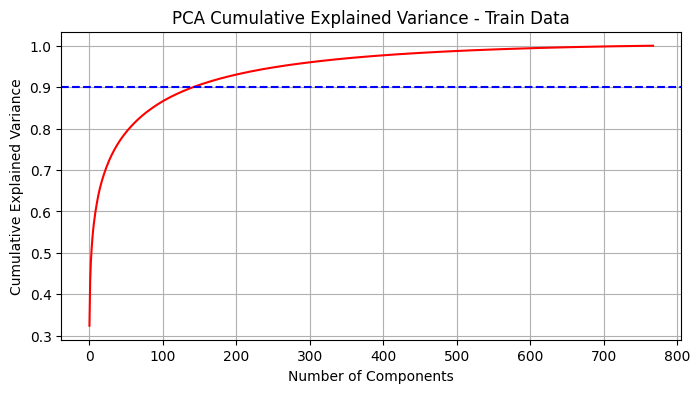

차원 축소 전 학습 데이터 형태: (6188, 768)
차원 축소 후 학습 데이터 형태: (6188, 143)
차원 축소 후 검증 데이터 형태: (1326, 143)
차원 축소 후 테스트 데이터 형태: (1327, 143)
PCA 선택 차원 수: 143


In [3]:
# 학습 데이터 기준으로만 PCA fit
pca = PCA(n_components=0.90, random_state=42)

X_emb_train_pca = pca.fit_transform(X_emb_train)
X_emb_val_pca = pca.transform(X_emb_val)
X_emb_test_pca = pca.transform(X_emb_test)

# 시각화도 학습 데이터 기준으로만 확인
pca_full = PCA().fit(X_emb_train)

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), color='red')
plt.axhline(y=0.9, color='blue', linestyle='--')
plt.title('PCA Cumulative Explained Variance - Train Data')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

print(f"차원 축소 전 학습 데이터 형태: {X_emb_train.shape}")
print(f"차원 축소 후 학습 데이터 형태: {X_emb_train_pca.shape}")
print(f"차원 축소 후 검증 데이터 형태: {X_emb_val_pca.shape}")
print(f"차원 축소 후 테스트 데이터 형태: {X_emb_test_pca.shape}")
print(f"PCA 선택 차원 수: {pca.n_components_}")

### 메타데이터 정규화 (StandardScaler)

- 메타데이터(별점, 텍스트 길이, 이모지 개수, 사진 개수)의 단위와 스케일이 서로 다르므로 표준화(평균 0, 표준편차 1)를 진행한다.
- 정규화를 통해 모델이 특정 메타데이터 컬럼에 과적합되거나 편향되는 것을 방지한다.
- `rating`은 이후 별점 정제 대상이므로 제외한다.
- 04번 노트북에서는 데이터 누수를 방지하기 위해 이 스케일러를 각 CV fold 내부에서 다시 학습한다.

In [4]:
# 학습 데이터 기준으로만 StandardScaler fit
scaler = StandardScaler()

X_meta_train_scaled = scaler.fit_transform(X_meta_train)
X_meta_val_scaled = scaler.transform(X_meta_val)
X_meta_test_scaled = scaler.transform(X_meta_test)

print(f"스케일링 전 학습 메타데이터 예시:\n{X_meta_train[0]}")
print(f"스케일링 후 학습 메타데이터 예시:\n{X_meta_train_scaled[0]}")
print(f"학습 메타데이터 형태: {X_meta_train_scaled.shape}")
print(f"검증 메타데이터 형태: {X_meta_val_scaled.shape}")
print(f"테스트 메타데이터 형태: {X_meta_test_scaled.shape}")

스케일링 전 학습 메타데이터 예시:
[52  0  1]
스케일링 후 학습 메타데이터 예시:
[-0.08208463 -0.15769423  0.12837092]
학습 메타데이터 형태: (6188, 3)
검증 메타데이터 형태: (1326, 3)
테스트 메타데이터 형태: (1327, 3)


### 특성 융합 (Feature Fusion) 및 정답지 추가

- PCA로 차원 축소한 임베딩과 정규화된 메타데이터를 수평 결합한다.
- 결합된 feature 컬럼은 `feat_0`, `feat_1` 형식으로 생성한다.
- 마지막 메타데이터 컬럼은 해석하기 쉽도록 이름을 다시 지정한다.
- 예측 대상 라벨은 `target_label` 컬럼으로 추가한다.

In [ ]:
# PCA 임베딩과 정규화된 메타데이터 결합
X_train_final = np.hstack([X_emb_train_pca, X_meta_train_scaled])
X_val_final = np.hstack([X_emb_val_pca, X_meta_val_scaled])
X_test_final = np.hstack([X_emb_test_pca, X_meta_test_scaled])

# PCA 차원 수 확인
pca_dim = X_emb_train_pca.shape[1]

# 컬럼명 생성
column_names = [f'feat_{i}' for i in range(X_train_final.shape[1])]

df_train_final = pd.DataFrame(X_train_final, columns=column_names)
df_val_final = pd.DataFrame(X_val_final, columns=column_names)
df_test_final = pd.DataFrame(X_test_final, columns=column_names)

# 정답 label 추가
df_train_final['target_label'] = y_train
df_val_final['target_label'] = y_val
df_test_final['target_label'] = y_test

# 마지막 3개 컬럼명을 메타데이터 이름으로 변경
rename_dict = {
    f'feat_{pca_dim}': 'meta_text_length',
    f'feat_{pca_dim + 1}': 'meta_emoji_count',
    f'feat_{pca_dim + 2}': 'meta_photo_count'
}

df_train_final = df_train_final.rename(columns=rename_dict)
df_val_final = df_val_final.rename(columns=rename_dict)
df_test_final = df_test_final.rename(columns=rename_dict)

print(f"PCA 차원 수: {pca_dim}")
print(f"메타데이터 차원 수: {len(meta_cols)}")
print(f"최종 학습 데이터프레임 형태: {df_train_final.shape}")
print(f"최종 검증 데이터프레임 형태: {df_val_final.shape}")
print(f"최종 테스트 데이터프레임 형태: {df_test_final.shape}")

df_train_final.head()

PCA dimension: 143
Metadata dimension: 3
Final train DataFrame shape: (6188, 147)
Final validation DataFrame shape: (1326, 147)
Final test DataFrame shape: (1327, 147)


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_137,feat_138,feat_139,feat_140,feat_141,feat_142,meta_text_length,meta_emoji_count,meta_photo_count,target_label
0,10.651446,-7.012393,2.687123,-0.529863,-0.301117,-1.294867,-0.092358,-0.591757,-1.351573,1.139234,...,0.069355,0.238329,0.056749,0.357367,-0.075046,-0.600133,-0.082085,-0.157694,0.128371,0
1,-1.469128,1.171573,-0.811785,-3.022355,-2.812106,-0.040618,-0.995097,0.470921,-0.825367,-0.247051,...,-0.644765,-0.145823,-0.404171,0.032655,0.347964,-0.075013,-0.403728,1.260981,-1.175996,0
2,-6.240137,-1.859460,-6.447095,-0.870578,1.621051,-3.420482,-1.412642,-1.875504,-1.406871,-3.181205,...,0.872266,-0.539745,0.194674,-0.124087,-0.679644,0.695139,-0.403728,-0.157694,0.128371,1
3,-15.023119,1.020796,6.497656,5.925089,-1.193808,2.092551,4.450782,-0.946491,1.149091,-3.115664,...,-0.055237,0.542410,0.634678,0.160665,-0.077129,-0.269379,-0.757536,-0.157694,-1.175996,0
4,3.807705,-0.339367,-0.118003,-3.310111,-1.996413,-3.045876,0.506315,1.118433,2.087950,-0.211993,...,0.281680,-0.548353,-0.116256,0.705312,0.507136,-0.042145,-0.307235,-0.157694,2.737104,0


### 최종 데이터 산출

In [6]:
train_output_csv = 'csv/final_hybrid_train.csv'
val_output_csv = 'csv/final_hybrid_val.csv'
test_output_csv = 'csv/final_hybrid_test.csv'

df_train_final.to_csv(train_output_csv, index=False, encoding='utf-8-sig')
df_val_final.to_csv(val_output_csv, index=False, encoding='utf-8-sig')
df_test_final.to_csv(test_output_csv, index=False, encoding='utf-8-sig')

print(f"학습 데이터가 {train_output_csv}로 저장되었습니다.")
print(f"검증 데이터가 {val_output_csv}로 저장되었습니다.")
print(f"테스트 데이터가 {test_output_csv}로 저장되었습니다.")

학습 데이터가 csv/final_hybrid_train.csv로 저장되었습니다.
검증 데이터가 csv/final_hybrid_val.csv로 저장되었습니다.
테스트 데이터가 csv/final_hybrid_test.csv로 저장되었습니다.
